# 03 - MNIST CNN Training

This notebook uses a Convolutional Neural Network (CNN) to classify MNIST digits.
CNNs exploit spatial structure in images, typically achieving 99.2-99.5% on MNIST.

**Key differences from the fully-connected approach:**
- Conv layers detect local patterns (edges, curves) regardless of position
- Pooling layers reduce spatial dimensions, providing translation invariance
- Far fewer parameters than equivalent fully-connected networks

In [1]:
import numpy as np
import duckdb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from tqdm.notebook import tqdm

## 1. Load Data from DuckDB

In [2]:
con = duckdb.connect(str(Path('../data/mnist.duckdb')), read_only=True)
train_data = con.execute("SELECT * FROM mnist WHERE split='train'").fetchnumpy()
test_data = con.execute("SELECT * FROM mnist WHERE split='test'").fetchnumpy()
con.close()

px_cols = [f'px{i}' for i in range(784)]
X_train = np.column_stack([train_data[c] for c in px_cols]).astype(np.float32) / 255.0
y_train = train_data['label'].astype(np.int64)
X_test = np.column_stack([test_data[c] for c in px_cols]).astype(np.float32) / 255.0
y_test = test_data['label'].astype(np.int64)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (60000, 784), Test: (10000, 784)


## 2. DataLoaders

In [3]:
BATCH_SIZE = 128

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

## 3. CNN Architecture

```
Input (784 flat) → Unflatten to (1, 28, 28)
→ Conv2d(1→32, 3x3) + BN + ReLU + MaxPool(2x2)  → (32, 14, 14)
→ Conv2d(32→64, 3x3) + BN + ReLU + MaxPool(2x2) → (64, 7, 7)
→ Flatten → Linear(3136→128) + ReLU + Dropout
→ Linear(128→10)
```

In [4]:
class MNISTCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Unflatten(1, (1, 28, 28)),
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 4. Training

In [5]:
EPOCHS = 20
LEARNING_RATE = 1e-3

model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Model parameters: 421,834
MNISTCNN(
  (net): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(1, 28, 28))
    (1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=3136, out_features=128, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in tqdm(range(EPOCHS), desc='Training'):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(correct / total)

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    history['test_loss'].append(running_loss / total)
    history['test_acc'].append(correct / total)

    scheduler.step(history['test_loss'][-1])

    print(f"Epoch {epoch+1:2d} | Train Loss: {history['train_loss'][-1]:.4f} Acc: {history['train_acc'][-1]:.4f} | "
          f"Test Loss: {history['test_loss'][-1]:.4f} Acc: {history['test_acc'][-1]:.4f}")

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.1628 Acc: 0.9491 | Test Loss: 0.0485 Acc: 0.9853
Epoch  2 | Train Loss: 0.0600 Acc: 0.9820 | Test Loss: 0.0351 Acc: 0.9885
Epoch  3 | Train Loss: 0.0465 Acc: 0.9851 | Test Loss: 0.0281 Acc: 0.9903
Epoch  4 | Train Loss: 0.0388 Acc: 0.9880 | Test Loss: 0.0262 Acc: 0.9918
Epoch  5 | Train Loss: 0.0342 Acc: 0.9891 | Test Loss: 0.0310 Acc: 0.9901
Epoch  6 | Train Loss: 0.0308 Acc: 0.9900 | Test Loss: 0.0282 Acc: 0.9909
Epoch  7 | Train Loss: 0.0265 Acc: 0.9915 | Test Loss: 0.0322 Acc: 0.9900
Epoch  8 | Train Loss: 0.0239 Acc: 0.9923 | Test Loss: 0.0281 Acc: 0.9913
Epoch  9 | Train Loss: 0.0136 Acc: 0.9955 | Test Loss: 0.0229 Acc: 0.9934
Epoch 10 | Train Loss: 0.0106 Acc: 0.9969 | Test Loss: 0.0272 Acc: 0.9918
Epoch 11 | Train Loss: 0.0094 Acc: 0.9970 | Test Loss: 0.0275 Acc: 0.9919
Epoch 12 | Train Loss: 0.0088 Acc: 0.9971 | Test Loss: 0.0278 Acc: 0.9930
Epoch 13 | Train Loss: 0.0086 Acc: 0.9970 | Test Loss: 0.0244 Acc: 0.9928
Epoch 14 | Train Loss: 0.0061 Acc: 0.9

## 5. Training Curves

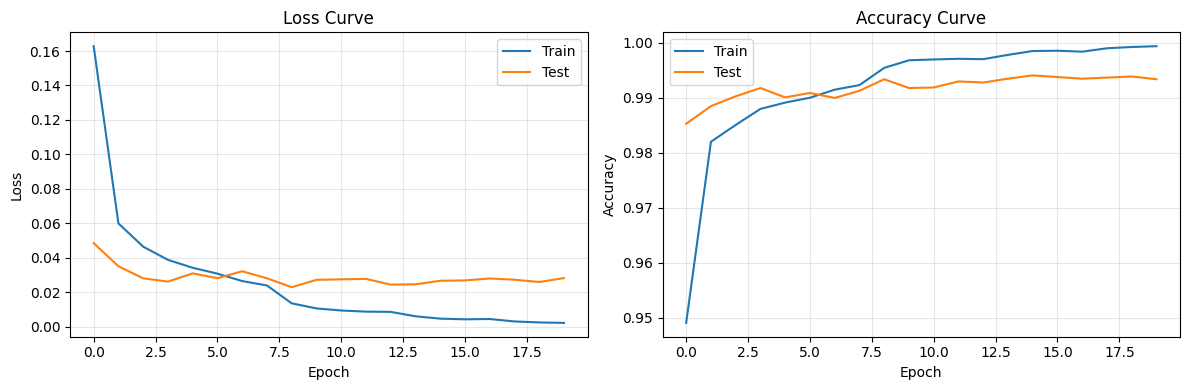

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['test_loss'], label='Test')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['test_acc'], label='Test')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

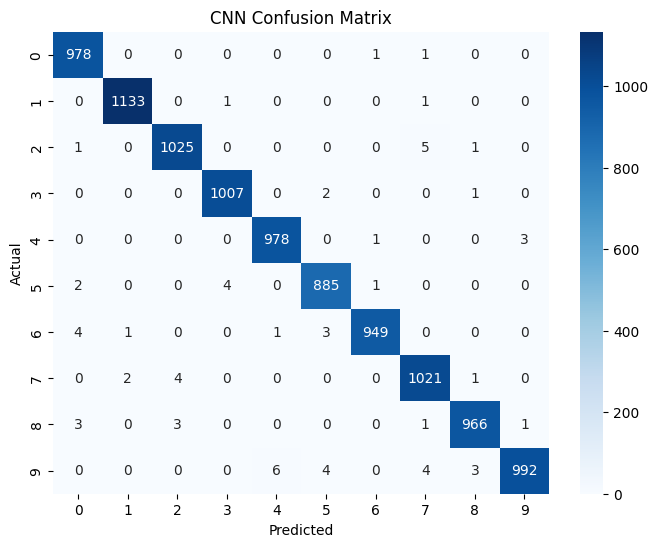

              precision    recall  f1-score   support

           0     0.9899    0.9980    0.9939       980
           1     0.9974    0.9982    0.9978      1135
           2     0.9932    0.9932    0.9932      1032
           3     0.9951    0.9970    0.9960      1010
           4     0.9929    0.9959    0.9944       982
           5     0.9899    0.9922    0.9910       892
           6     0.9968    0.9906    0.9937       958
           7     0.9884    0.9932    0.9908      1028
           8     0.9938    0.9918    0.9928       974
           9     0.9960    0.9832    0.9895      1009

    accuracy                         0.9934     10000
   macro avg     0.9933    0.9933    0.9933     10000
weighted avg     0.9934    0.9934    0.9934     10000



In [8]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, digits=4))

## 7. Save Model

In [9]:
import pandas as pd

# Save training history to DuckDB
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, EPOCHS + 1)

con = duckdb.connect(str(Path('../data/mnist.duckdb')))
con.execute('DROP TABLE IF EXISTS cnn_training_history')
con.execute('CREATE TABLE cnn_training_history AS SELECT * FROM history_df')
con.close()

# Save model weights
torch.save(model.state_dict(), '../data/mnist_cnn_model.pth')
print(f'CNN model saved. Final test accuracy: {history["test_acc"][-1]:.4f}')

CNN model saved. Final test accuracy: 0.9934


## 9. Experiment Ideas

Try changing these parameters and re-running to see the effect:

| Parameter | Current | Try |
|-----------|---------|-----|
| `LEARNING_RATE` | 0.001 | 0.01, 0.0001 |
| `HIDDEN1` | 256 | 64, 512 |
| `HIDDEN2` | 128 | 32, 256 |
| `DROPOUT` | 0.2 | 0.0, 0.5 |
| `EPOCHS` | 15 | 5, 30 |
| `BATCH_SIZE` | 128 | 32, 512 |
| Optimizer | Adam | SGD(lr=0.01, momentum=0.9) |